# Power and Number of Permutations Generate Data

This notebook reproduces the data generation process for Figures 1, 2, 3, and 4 in the paper "Sequential Monte-Carlo testing by betting".
We simulate trials to calculate power and the number of permutations required by various betting strategies.
Note: For execution speed, you might want to run this with `m = 100` or `m = 2000` (as in paper) depending on your patience!

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm, binom
import os

# Set seed for reproducibility
np.random.seed(123)

## Setting Parameters

In [2]:
n = 1000 # Number of obs. per trial
m = 200 # Reduced from 2000 for faster execution in python. Change back to 2000 to perfectly reproduce the paper.
B = 1000 # Number of perm. per trial
mus = [0.01, 0.05, 0.1, 0.15, 0.2, 0.3, 0.4, 0.5] # Strength of the alternative
prop_treated = 0.5 # Probability of obs. being treated
alpha = 0.05 # Individual significance level. For power_alpha001 results change to alpha = 0.01.
c_param = alpha * 0.90 # Parameter for binomial mixture strategy
p_zero = 1 / np.ceil(np.sqrt(2 * np.pi * np.exp(1 / 6)) / alpha) # Parameter for binomial strategy
h_bc = alpha * B # Parameter for Besag Clifford

# Create results directory if it doesn't exist
os.makedirs("results", exist_ok=True)

## Initialize Power and Permutation Vectors

In [3]:
power_bin = np.zeros(len(mus))
power_bin_r = np.zeros(len(mus))
power_agg = np.zeros(len(mus))
power_bc = np.zeros(len(mus))
power_bm = np.zeros(len(mus))
power_bm_r = np.zeros(len(mus))

nPerm_bc = np.zeros(len(mus))
nPerm_rej_bc = np.zeros(len(mus))
nPerm_stop_bc = np.zeros(len(mus))

nPerm = np.zeros(len(mus))
nPerm_rej = np.zeros(len(mus))
nPerm_stop = np.zeros(len(mus))

nPerm_agg = np.zeros(len(mus))
nPerm_agg_rej = np.zeros(len(mus))
nPerm_agg_stop = np.zeros(len(mus))

nPerm_bm = np.zeros(len(mus))
nPerm_bm_rej = np.zeros(len(mus))
nPerm_bm_stop = np.zeros(len(mus))

## Simulation Loop
The core loop iterates over different alternative strengths (`mus`), generating `m` trials.
For each trial, we perform `B` permutations and calculate the stopping index and decision based on various strategies.

In [4]:
counter = 0

print(f"Starting simulation. Number of trials: {m}, Permutations: {B}")

for mu in mus:
    print(f"Simulating for mu = {mu}...")
    
    idx_dec_bc = np.full(m, B)
    dec_bc = np.zeros(m)
    
    idx_dec = np.full(m, B)
    dec_bin = np.zeros(m)
    dec_bin_r = np.zeros(m)
    
    idx_dec_agg = np.full(m, B)
    dec_agg = np.zeros(m)
    
    idx_dec_bm = np.full(m, B)
    dec_bm = np.zeros(m)
    dec_bm_r = np.zeros(m)
    
    for j in range(m):
        X = np.random.randn(n)
        treated = np.random.rand(n) >= prop_treated
        X = X + mu * treated
        
        test_stat = np.mean(X[treated]) - np.mean(X[~treated])
        
        test_stat_perm = np.zeros(B)
        
        bet_bin = []
        bet_agg = []
        
        rank = 1
        
        wealth_bin = [1.0]
        wealth_agg = [1.0]
        wealth_bm = []
        bc_count = 1
        
        # Pre-generate permutations for speed
        # Generating a matrix of Bxn permutations is faster than generating one by one
        # but could take too much memory. We will stick to one-by-one.
        
        for i in range(B):
            i_R = i + 1 # 1-based indexing for formulas
            X_perm = np.random.permutation(X)
            test_stat_perm[i] = np.mean(X_perm[treated]) - np.mean(X_perm[~treated])
            
            if test_stat_perm[i] >= test_stat:
                if (wealth_bin[-1] * p_zero * (i_R + 1) / rank) <= alpha:
                    bet_bin.append(0.0)
                else:
                    bet_bin.append(p_zero * (i_R + 1) / rank)
                bet_agg.append(0.0)
                rank += 1
            else:
                if (wealth_bin[-1] * p_zero * (i_R + 1) / rank) <= alpha:
                    bet_bin.append((i_R + 1) / (i_R - rank + 1))
                else:
                    bet_bin.append((1 - p_zero) * (i_R + 1) / (i_R - rank + 1))
                bet_agg.append((i_R + 1) / i_R)
                
            wealth_bin.append(wealth_bin[-1] * bet_bin[-1])
            
            # Use np.min(wealth_bin) and np.max(wealth_bin) incrementally
            if (min(wealth_bin) <= alpha or max(wealth_bin) > (1 / alpha)) and idx_dec[j] == B:
                idx_dec[j] = i_R
                
            wealth_agg.append(wealth_agg[-1] * bet_agg[-1])
            if (min(wealth_agg) <= alpha or max(wealth_agg) > (1 / alpha)) and idx_dec_agg[j] == B:
                idx_dec_agg[j] = i_R
                
            if (rank - 1) == h_bc and bc_count == 1 and i_R < B:
                dec_bc[j] = -1
                idx_dec_bc[j] = i_R
                bc_count = 0
            elif i_R == B and bc_count == 1:
                idx_dec_bc[j] = i_R
                dec_bc[j] = 1
                
            # wealth_bm
            val = (1 - binom.cdf(rank - 1 - 1, i_R + 1, c_param)) / c_param # rank-1 in R is rank-1 in Python (number of success). Python binom.cdf(k, n, p) computes up to k.
            wealth_bm.append(val)
            
            if ((min(wealth_bm) <= alpha and i_R > 1) or max(wealth_bm) > (1 / alpha)) and idx_dec_bm[j] == B:
                idx_dec_bm[j] = i_R

        # Decisions
        if wealth_bin[idx_dec[j]-1 + 1] >= (1 / alpha): # +1 because wealth_bin has initial 1.0
            dec_bin[j] = 1
        elif wealth_bin[idx_dec[j]-1 + 1] < alpha:
            dec_bin[j] = -1
        else:
            dec_bin[j] = 0
            
        if wealth_bin[idx_dec[j]-1 + 1] >= (np.random.rand() / alpha):
            dec_bin_r[j] = 1
        elif wealth_bin[idx_dec[j]-1 + 1] < alpha:
            dec_bin_r[j] = -1
        else:
            dec_bin_r[j] = 0
            
        if wealth_agg[idx_dec_agg[j]-1 + 1] >= (1 / alpha):
            dec_agg[j] = 1
        elif wealth_agg[idx_dec_agg[j]-1 + 1] < alpha:
            dec_agg[j] = -1
        else:
            dec_agg[j] = 0
            
        if wealth_bm[idx_dec_bm[j]-1] >= (1 / alpha):
            dec_bm[j] = 1
        elif wealth_bm[idx_dec_bm[j]-1] < alpha:
            dec_bm[j] = -1
        else:
            dec_bm[j] = 0
            
        if wealth_bm[idx_dec_bm[j]-1] >= (np.random.rand() / alpha):
            dec_bm_r[j] = 1
        elif wealth_bm[idx_dec_bm[j]-1] < alpha:
            dec_bm_r[j] = -1
        else:
            dec_bm_r[j] = 0

    power_bin[counter] = np.mean(dec_bin > 0)
    power_bin_r[counter] = np.mean(dec_bin_r > 0)
    power_bc[counter] = np.mean(dec_bc > 0)
    power_agg[counter] = np.mean(dec_agg > 0)
    power_bm[counter] = np.mean(dec_bm > 0)
    power_bm_r[counter] = np.mean(dec_bm_r > 0)

    nPerm[counter] = np.mean(idx_dec)
    nPerm_rej[counter] = np.mean(idx_dec[dec_bin == 1]) if sum(dec_bin == 1)>0 else 0
    nPerm_stop[counter] = np.mean(idx_dec[dec_bin == -1]) if sum(dec_bin == -1)>0 else 0

    nPerm_bc[counter] = np.mean(idx_dec_bc)
    nPerm_rej_bc[counter] = np.mean(idx_dec_bc[dec_bc == 1]) if sum(dec_bc == 1)>0 else 0
    nPerm_stop_bc[counter] = np.mean(idx_dec_bc[dec_bc == -1]) if sum(dec_bc == -1)>0 else 0

    nPerm_agg[counter] = np.mean(idx_dec_agg)
    nPerm_agg_rej[counter] = np.mean(idx_dec_agg[dec_agg == 1]) if sum(dec_agg == 1)>0 else 0
    nPerm_agg_stop[counter] = np.mean(idx_dec_agg[dec_agg == -1]) if sum(dec_agg == -1)>0 else 0

    nPerm_bm[counter] = np.mean(idx_dec_bm)
    nPerm_bm_rej[counter] = np.mean(idx_dec_bm[dec_bm == 1]) if sum(dec_bm == 1)>0 else 0
    nPerm_bm_stop[counter] = np.mean(idx_dec_bm[dec_bm == -1]) if sum(dec_bm == -1)>0 else 0
    
    counter += 1

Starting simulation. Number of trials: 200, Permutations: 1000
Simulating for mu = 0.01...


Simulating for mu = 0.05...


Simulating for mu = 0.1...


Simulating for mu = 0.15...


Simulating for mu = 0.2...


Simulating for mu = 0.3...


Simulating for mu = 0.4...


Simulating for mu = 0.5...


## Save Results
We save the results into a dataframe so we can use them for plotting in later sections.

In [5]:
results_dict = {
    'mus': mus,
    'power_bin': power_bin, 'power_bin_r': power_bin_r, 'power_bc': power_bc, 
    'power_agg': power_agg, 'power_bm': power_bm, 'power_bm_r': power_bm_r,
    'nPerm': nPerm, 'nPerm_rej': nPerm_rej, 'nPerm_stop': nPerm_stop,
    'nPerm_bc': nPerm_bc, 'nPerm_rej_bc': nPerm_rej_bc, 'nPerm_stop_bc': nPerm_stop_bc,
    'nPerm_agg': nPerm_agg, 'nPerm_agg_rej': nPerm_agg_rej, 'nPerm_agg_stop': nPerm_agg_stop,
    'nPerm_bm': nPerm_bm, 'nPerm_bm_rej': nPerm_bm_rej, 'nPerm_bm_stop': nPerm_bm_stop
}
df_results = pd.DataFrame(results_dict)
df_results.to_csv("results/power_alpha005.csv", index=False)
print("Saved results to results/power_alpha005.csv")

Saved results to results/power_alpha005.csv


## Generate Plots (Figure 1-4 Equivalents)

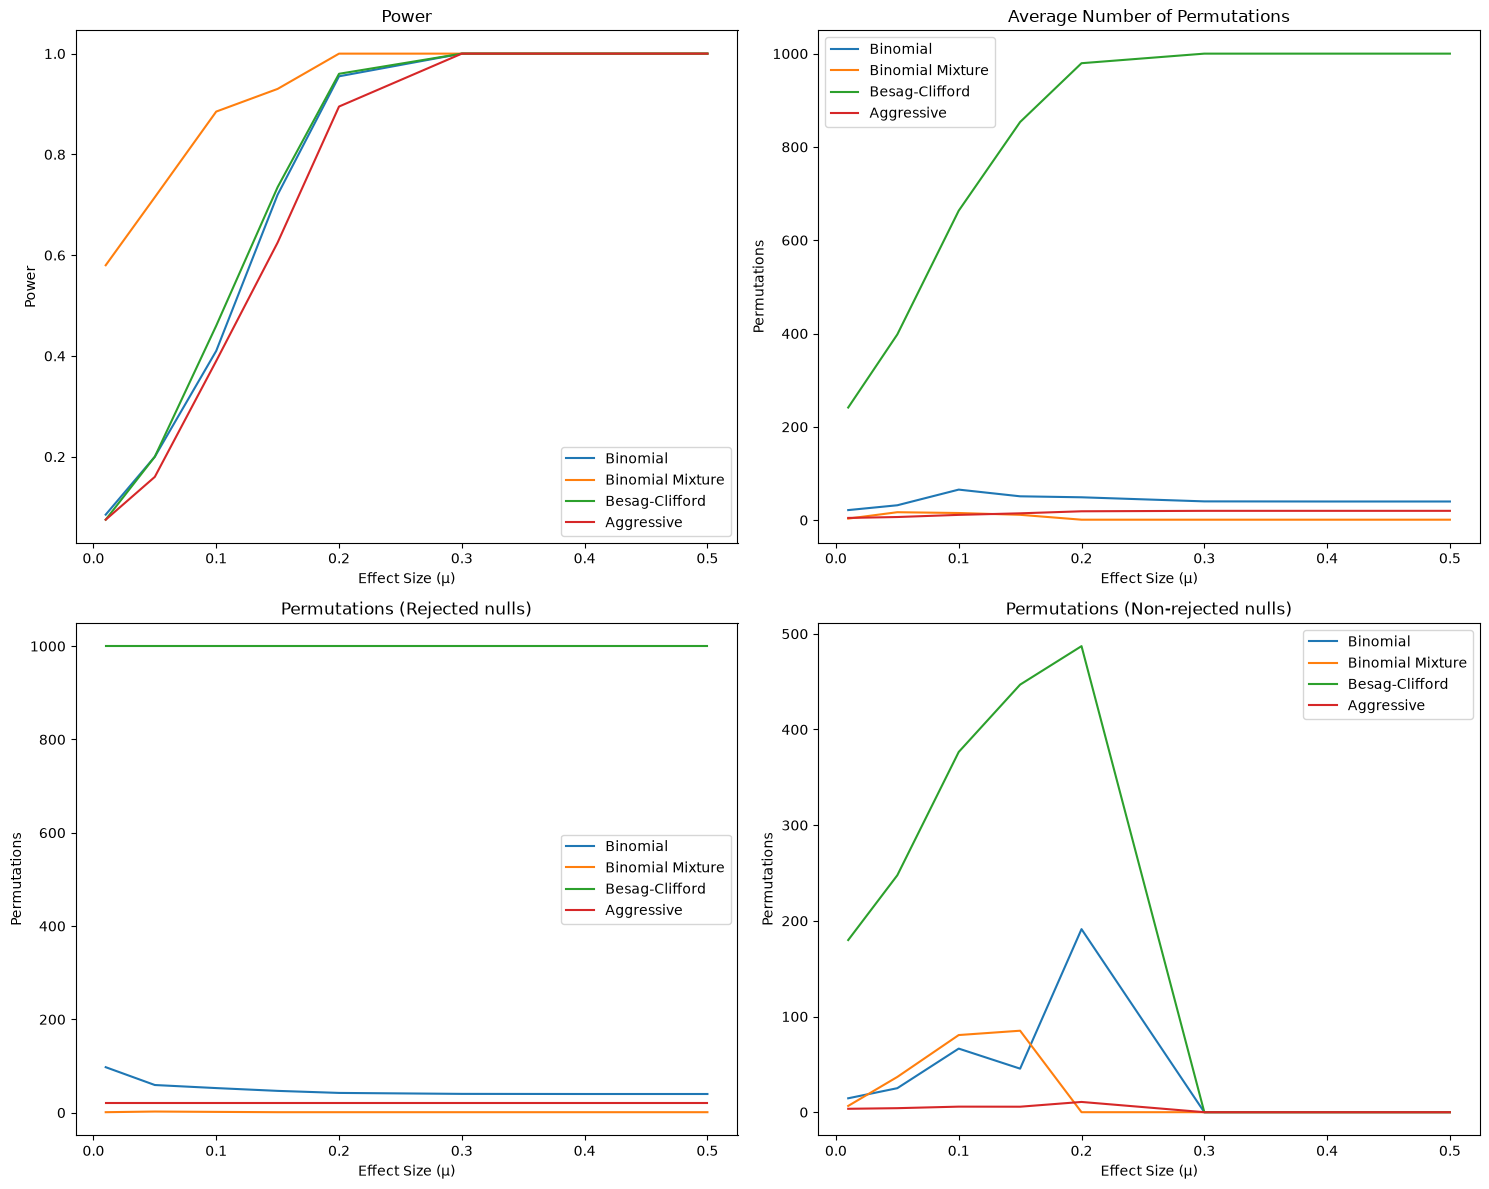

In [6]:
df = pd.read_csv("results/power_alpha005.csv")

fig, axs = plt.subplots(2, 2, figsize=(15, 12))

# Subplot 1: Power (All strategies)
axs[0, 0].plot(df['mus'], df['power_bin'], label='Binomial')
axs[0, 0].plot(df['mus'], df['power_bm'], label='Binomial Mixture')
axs[0, 0].plot(df['mus'], df['power_bc'], label='Besag-Clifford')
axs[0, 0].plot(df['mus'], df['power_agg'], label='Aggressive')
axs[0, 0].set_title('Power')
axs[0, 0].set_xlabel('Effect Size (\u03BC)')
axs[0, 0].set_ylabel('Power')
axs[0, 0].legend()

# Subplot 2: Average number of permutations
axs[0, 1].plot(df['mus'], df['nPerm'], label='Binomial')
axs[0, 1].plot(df['mus'], df['nPerm_bm'], label='Binomial Mixture')
axs[0, 1].plot(df['mus'], df['nPerm_bc'], label='Besag-Clifford')
axs[0, 1].plot(df['mus'], df['nPerm_agg'], label='Aggressive')
axs[0, 1].set_title('Average Number of Permutations')
axs[0, 1].set_xlabel('Effect Size (\u03BC)')
axs[0, 1].set_ylabel('Permutations')
axs[0, 1].legend()

# Subplot 3: Permutations for rejected
axs[1, 0].plot(df['mus'], df['nPerm_rej'], label='Binomial')
axs[1, 0].plot(df['mus'], df['nPerm_bm_rej'], label='Binomial Mixture')
axs[1, 0].plot(df['mus'], df['nPerm_rej_bc'], label='Besag-Clifford')
axs[1, 0].plot(df['mus'], df['nPerm_agg_rej'], label='Aggressive')
axs[1, 0].set_title('Permutations (Rejected nulls)')
axs[1, 0].set_xlabel('Effect Size (\u03BC)')
axs[1, 0].set_ylabel('Permutations')
axs[1, 0].legend()

# Subplot 4: Permutations for non-rejected
axs[1, 1].plot(df['mus'], df['nPerm_stop'], label='Binomial')
axs[1, 1].plot(df['mus'], df['nPerm_bm_stop'], label='Binomial Mixture')
axs[1, 1].plot(df['mus'], df['nPerm_stop_bc'], label='Besag-Clifford')
axs[1, 1].plot(df['mus'], df['nPerm_agg_stop'], label='Aggressive')
axs[1, 1].set_title('Permutations (Non-rejected nulls)')
axs[1, 1].set_xlabel('Effect Size (\u03BC)')
axs[1, 1].set_ylabel('Permutations')
axs[1, 1].legend()

plt.tight_layout()
plt.savefig('results/Figure_1_to_4.png')
plt.show()